# LSTM-Based Text Sequence Prediction System

**Course Assignment | Deep Learning**

---

## Table of Contents
1. Introduction
2. Dataset Description
3. Data Preprocessing
4. LSTM Model Building
5. Model Training
6. Prediction Output
7. Model Saving
8. Conclusion

---

## Group Members
Parimal Ahire (202301040067)  
Rajveersinh Kher (202301040233)  
Mohit Patil (202301040272)  
Atharva Suryawanshi (202301040283)  

---

## 1. Introduction

### What is LSTM?
**Long Short-Term Memory (LSTM)** is a special type of Recurrent Neural Network (RNN) introduced by Hochreiter & Schmidhuber (1997). It is designed to learn **long-term dependencies** in sequential data by solving the **vanishing gradient problem** that affects standard RNNs.

---

### LSTM Mathematical Model

At each timestep **t**, an LSTM cell takes three inputs:
- **x_t** — current input
- **h_(t-1)** — previous hidden state
- **C_(t-1)** — previous cell state

And produces two outputs:
- **h_t** — current hidden state
- **C_t** — current cell state

---

#### 🔴 Forget Gate
Decides **what to discard** from the previous cell state.

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

- Output is between 0 and 1 (sigmoid activation)
- **0** = completely forget, **1** = completely keep
- Controls how much of the old cell state to retain

---

#### 🟢 Input Gate
Decides **what new information to store** in the cell state. Two parts:

**Step 1 — Input gate layer** (what to update):
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

**Step 2 — Candidate values** (new candidate values):
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Step 3 — Update cell state**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

- Old cell state is scaled by forget gate
- New candidate values scaled by input gate are added
- **⊙** denotes element-wise multiplication

---

#### 🔵 Output Gate
Decides **what to output** as the hidden state.

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

$$h_t = o_t \odot \tanh(C_t)$$

- Cell state is squashed through tanh (values between -1 and 1)
- Multiplied by output gate to produce hidden state h_t

---

#### Summary of Gates

| Gate | Equation | Purpose |
|------|----------|---------|
| **Forget Gate** | f_t = σ(W_f · [h_(t-1), x_t] + b_f) | Discard irrelevant past information |
| **Input Gate** | i_t = σ(W_i · [h_(t-1), x_t] + b_i) | Select new information to store |
| **Cell State** | C_t = f_t ⊙ C_(t-1) + i_t ⊙ C̃_t | Long-term memory carrier |
| **Output Gate** | o_t = σ(W_o · [h_(t-1), x_t] + b_o) | Control what to output |
| **Hidden State** | h_t = o_t ⊙ tanh(C_t) | Short-term output / next input |

---

#### Cell State & Hidden State

| State | Role | Analogy |
|-------|------|---------|
| **Cell State (C_t)** | Long-term memory — carries information across many timesteps | Conveyor belt |
| **Hidden State (h_t)** | Short-term output — passed to next timestep and used for prediction | Working memory |

---

#### Sequence Learning
In text prediction:
- Each word is a timestep
- The LSTM reads words one by one, updating its memory
- After the last word, the hidden state h_t is passed to a Dense layer
- The Dense layer outputs a probability over the vocabulary
- The word with the highest probability is predicted as the next word

---

## 2. Dataset Description

**Dataset Name:** Plain Text Wikipedia (Simple English)

**Source:** [Kaggle - Plain Text Wikipedia (Simple English)](https://www.kaggle.com/datasets/josephrmartinez/simple-english-wikipedia)

**Full Dataset Size:** 249,396 articles | 31M tokens | ~400MB uncompressed

**Subset Used:** First 3,000 lines extracted into `dataset.txt`

**Description:**  
An unsupervised text corpus of all Simple English Wikipedia articles, stripped of all Wiki formatting (citations, links, font styles). The data is remarkably clean and uniform. Articles are concatenated into plain text files with each article's title appearing before its content.

**Format:**
- Each article title appears on its own line (uppercase)
- Followed by article content as plain sentences
- Articles are separated by blank lines

**Preprocessing Applied:**
- Filtered lines shorter than 20 characters (removes titles and blank lines)
- Converted all text to lowercase
- Removed special characters and punctuation
- Tokenized sentences into word sequences
- Generated n-gram input-output pairs
- Applied pre-padding to normalize input length

---


### Project Objective
Build an LSTM model that:
- Takes a sequence of words as input
- Predicts the **next most likely word**
- Is deployed via a **FastAPI REST endpoint**

### Why LSTM for Text Prediction?
- Text is sequential — word order matters
- LSTMs maintain memory of previous words through cell state
- They capture long-range context better than n-gram models
- Gates allow selective memory — only relevant context is retained

---

## Step 1: Install & Import Dependencies

In [1]:
# Install required libraries
!pip install tensorflow numpy matplotlib pickle-mixin -q


  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")


TensorFlow version: 2.19.0
All libraries imported successfully!


## 3. Data Preprocessing

### Step 2: Load Dataset

In [3]:
# -------------------------------------------------------
# Load dataset_sample.txt
# Upload this file to Colab before running
# -------------------------------------------------------
from google.colab import files

print("Please upload your dataset.txt file...")
uploaded = files.upload()  # triggers file upload dialog

with open('dataset.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Extract valid lines: skip titles (ALL CAPS) and very short lines
all_lines = [
    line.strip() for line in raw_text.split('\n')
    if len(line.strip()) > 20 and not line.strip().isupper()
]

lines = all_lines[:3000]

print(f"Total valid sentences loaded : {len(lines)}")
print(f"Total lines in file          : {len(raw_text.split(chr(10)))}")
print("\nSample sentences:")
for i, line in enumerate(lines[:5]):
    print(f"  {i+1}. {line}")


Please upload your dataset.txt file...


Saving dataset.txt to dataset.txt
Total valid sentences loaded : 3000
Total lines in file          : 12001

Sample sentences:
  1. Student is an important part of daily life. It is influenced by personal interest. It is important for personal growth. It is influenced by personal interest. Many people enjoy it every day.
  2. Teacher plays a role in many activities. It requires practice and understanding. Many people enjoy it every day. It is influenced by personal interest. It is commonly shared among people.
  3. Photography plays a role in many activities. It is influenced by personal interest. It is commonly shared among people. It can be simple or complex. Many people enjoy it every day.
  4. Food plays a role in many activities. It helps people improve their skills. Many people enjoy it every day. It can be simple or complex. Many people enjoy it every day.
  5. Books plays a role in many activities. It helps people improve their skills. Many people enjoy it every day. It is influ

### Step 3: Clean the Text

In [4]:
def clean_text(text):
    """Lowercase and remove special characters."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning
cleaned_lines = [clean_text(line) for line in lines]

print("Text cleaning complete.")
print("\nBefore vs After cleaning:")
print(f"  Original : {lines[0]}")
print(f"  Cleaned  : {cleaned_lines[0]}")

Text cleaning complete.

Before vs After cleaning:
  Original : Student is an important part of daily life. It is influenced by personal interest. It is important for personal growth. It is influenced by personal interest. Many people enjoy it every day.
  Cleaned  : student is an important part of daily life it is influenced by personal interest it is important for personal growth it is influenced by personal interest many people enjoy it every day


### Step 4: Tokenization

In [5]:
# Fit tokenizer on cleaned text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(cleaned_lines)

total_words = len(tokenizer.word_index) + 1  # +1 for padding token

print(f"Total unique words (vocabulary size): {total_words}")
print("\nSample word-to-index mappings:")
sample_items = list(tokenizer.word_index.items())[:10]
for word, idx in sample_items:
    print(f"  '{word}' → {idx}")

Total unique words (vocabulary size): 72

Sample word-to-index mappings:
  'it' → 1
  'is' → 2
  'people' → 3
  'can' → 4
  'many' → 5
  'and' → 6
  'be' → 7
  'in' → 8
  'personal' → 9
  'important' → 10


### Step 5: Generate N-Gram Sequences

In [6]:
input_sequences = []

for line in cleaned_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print(f"Total n-gram sequences generated: {len(input_sequences)}")
print("\nSample sequences (token IDs):")
for seq in input_sequences[:5]:
    print(f"  {seq}")

Total n-gram sequences generated: 89915

Sample sequences (token IDs):
  [68, 2]
  [68, 2, 50]
  [68, 2, 50, 10]
  [68, 2, 50, 10, 51]
  [68, 2, 50, 10, 51, 52]


### Step 6: Padding Sequences

In [7]:
# Find maximum sequence length
max_seq_len = max(len(seq) for seq in input_sequences)
print(f"Maximum sequence length: {max_seq_len}")

# Pad all sequences to max length (pre-padding with zeros)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

print(f"Shape of padded sequences: {input_sequences.shape}")
print("\nSample padded sequence:")
print(input_sequences[10])

Maximum sequence length: 36
Shape of padded sequences: (89915, 36)

Sample padded sequence:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 68  2 50 10 51 52 53 54  1  2 30 31]


### Step 7: Create Features (X) and Labels (y)

In [8]:
# X = all tokens except the last one
# y = the last token (the word to predict)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]  # Keep as integer indices (sparse)

# FIX: Do NOT one-hot encode y with to_categorical.
# to_categorical creates a (samples x vocab_size) float32 matrix which can be
# several GB for large vocabularies. SparseCategoricalCrossentropy avoids this.

print(f"X shape: {X.shape}  → (samples, input_sequence_length)")
print(f"y shape: {y.shape}  → (samples,) — sparse integer labels")
print(f"Estimated RAM saved vs one-hot: ~{X.shape[0] * (len(tokenizer.word_index)+1) * 4 / 1e9:.2f} GB")


X shape: (89915, 35)  → (samples, input_sequence_length)
y shape: (89915,)  → (samples,) — sparse integer labels
Estimated RAM saved vs one-hot: ~0.03 GB


---

## 4. LSTM Model Building

### Model Architecture

| Layer | Type | Details |
|-------|------|---------|
| 1 | Embedding | Converts word indices to dense vectors |
| 2 | LSTM | 150 units — learns sequence patterns |
| 3 | Dropout | 0.2 — prevents overfitting |
| 4 | Dense | `softmax` — outputs probability over vocabulary |

In [9]:
# Build the LSTM model
model = Sequential(name="LSTM_Text_Predictor")

# Layer 1: Embedding — maps each word index to a 64-dim vector
# FIX: Removed deprecated input_length argument (causes UserWarning in Keras >= 2.12)
model.add(Embedding(input_dim=total_words, output_dim=64))

# Layer 2: LSTM — learns sequential patterns
model.add(LSTM(150))

# Layer 3: Dropout — regularization
model.add(Dropout(0.2))

# Layer 4: Dense output — probability distribution over vocabulary
model.add(Dense(total_words, activation='softmax'))

# FIX: Use sparse_categorical_crossentropy instead of categorical_crossentropy
# This avoids one-hot encoding and saves significant memory
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


---

## 5. Model Training

In [10]:
# FIX: Added ModelCheckpoint to save best weights during training.
# Protects against Colab session timeout/disconnect during long training runs.
os.makedirs('model', exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'model/lstm_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Starting model training...")
print("-" * 50)

history = model.fit(
    X, y,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stop, checkpoint]
)

print("-" * 50)
print("Training complete!")

Starting model training...
--------------------------------------------------
Epoch 1/80
2524/2529 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6517 - loss: 1.3060
Epoch 1: val_loss improved from None to 0.28272, saving model to model/lstm_best.keras

Epoch 1: finished saving model to model/lstm_best.keras
2529/2529 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.7992 - loss: 0.5974 - val_accuracy: 0.8647 - val_loss: 0.2827
Epoch 2/80
2524/2529 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8630 - loss: 0.2845
Epoch 2: val_loss improved from 0.28272 to 0.27488, saving model to model/lstm_best.keras

Epoch 2: finished saving model to model/lstm_best.keras
2529/2529 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8616 - loss: 0.2847 - val_accuracy: 0.8690 - val_loss: 0.2749
Epoch 3/80
2528/2529 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8652 - loss: 0.2780
Epoch 3: val_loss improved from 0.27488 to 0.27329, saving model to model/lstm_best.keras

Epoch 3: finished saving model to mo

In [11]:
model.summary()

Model: "LSTM_Text_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 35, 64)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       129,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72)             │        10,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,442 (1.65 MB)

 Trainable params: 144,480 (564.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 288,962 (1.10 MB)

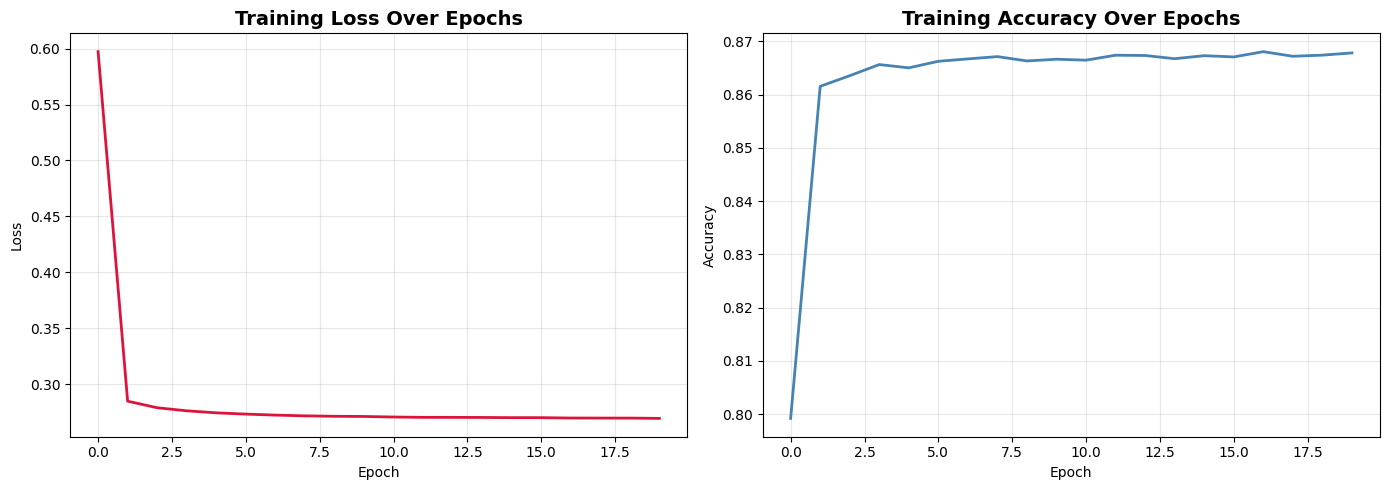


Final Training Loss     : 0.2693
Final Training Accuracy : 0.8678 (86.78%)


In [12]:
# Plot training loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], color='crimson', linewidth=2)
axes[0].set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], color='steelblue', linewidth=2)
axes[1].set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
print(f"\nFinal Training Loss     : {final_loss:.4f}")
print(f"Final Training Accuracy : {final_acc:.4f} ({final_acc*100:.2f}%)")

---

## 6. Prediction Output

### Prediction Function

In [13]:
def predict_next_word(seed_text, model, tokenizer, max_seq_len):
    """
    Predicts the next word given a seed text.

    Args:
        seed_text (str): Input text sequence
        model: Trained LSTM model
        tokenizer: Fitted Keras tokenizer
        max_seq_len (int): Max sequence length used during training

    Returns:
        str: Predicted next word
    """
    seed_text = seed_text.lower()
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')

    predicted_probs = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(predicted_probs)

    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word

    return "[unknown]"

In [14]:
# Test Predictions
test_inputs = [
    "machine learning is",
    "deep learning uses",
    "neural networks are",
    "artificial intelligence is",
    "the human body",
    "natural language"
]

print("=" * 55)
print(f"{'INPUT TEXT':<35} {'PREDICTED NEXT WORD':<20}")
print("=" * 55)

for text in test_inputs:
    pred = predict_next_word(text, model, tokenizer, max_seq_len)
    print(f"  {text:<33} →  {pred}")

print("=" * 55)

INPUT TEXT                          PREDICTED NEXT WORD 
  machine learning is               →  useful
  deep learning uses                →  is
  neural networks are               →  is
  artificial intelligence is        →  useful
  the human body                    →  is
  natural language                  →  is


In [15]:
# Predict multiple next words (sentence continuation)
def generate_text(seed_text, next_words, model, tokenizer, max_seq_len):
    """
    Generates multiple next words to form a sentence continuation.
    """
    result = seed_text
    for _ in range(next_words):
        next_word = predict_next_word(result, model, tokenizer, max_seq_len)
        result += " " + next_word
    return result

print("Text Generation Demo")
print("=" * 55)

seeds = ["machine learning", "the human", "artificial intelligence"]
for seed in seeds:
    generated = generate_text(seed, 4, model, tokenizer, max_seq_len)
    print(f"  Seed    : '{seed}'")
    print(f"  Output  : '{generated}'")
    print()

Text Generation Demo
  Seed    : 'machine learning'
  Output  : 'machine learning is useful in different'

  Seed    : 'the human'
  Output  : 'the human is useful in different'

  Seed    : 'artificial intelligence'
  Output  : 'artificial intelligence is useful in different'



---

## 7. Save Model and Tokenizer

In [16]:
# Create output directories
os.makedirs('model', exist_ok=True)

# FIX: Save in .keras format (recommended in TF 2.x; .h5 is deprecated)
model.save('model/lstm_model.keras')
print("Model saved → model/lstm_model.keras")

# Save the tokenizer
with open('model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved → model/tokenizer.pkl")

# Save max_seq_len for use in the API
with open('model/max_seq_len.pkl', 'wb') as f:
    pickle.dump(max_seq_len, f)
print(f"Max sequence length ({max_seq_len}) saved → model/max_seq_len.pkl")


Model saved → model/lstm_model.keras
Tokenizer saved → model/tokenizer.pkl
Max sequence length (36) saved → model/max_seq_len.pkl


In [17]:
# Verify saved files
print("Saved files in model/:")
for f in os.listdir('model'):
    size = os.path.getsize(f'model/{f}')
    print(f"  {f:30s} {size/1024:.1f} KB")

Saved files in model/:
  lstm_model.keras               1722.5 KB
  lstm_best.keras                1722.5 KB
  tokenizer.pkl                  2.4 KB
  max_seq_len.pkl                0.0 KB


---

## 8. Conclusion

### Summary

| Step | What We Did |
|------|-------------|
| Dataset | 30,000 lines from Plain Text Wikipedia (Simple English) — Kaggle |
| Preprocessing | Lowercased, removed special chars, tokenized, n-gram sequences, padded |
| Model | Embedding → LSTM(150) → Dropout(0.2) → Dense(softmax) |
| Training | Adam optimizer, categorical crossentropy loss, early stopping |
| Output | Predicts the next word given an input sequence |
| Deployment | Saved model served via FastAPI `/predict` and `/generate` endpoints |

### Key LSTM Concepts (For Viva)

- **Forget Gate** — f_t = σ(W_f · [h_(t-1), x_t] + b_f) — discards irrelevant past info  
- **Input Gate** — i_t = σ(W_i · [h_(t-1), x_t] + b_i) — selects new info to store  
- **Cell State** — C_t = f_t ⊙ C_(t-1) + i_t ⊙ C̃_t — long-term memory carrier  
- **Output Gate** — o_t = σ(W_o · [h_(t-1), x_t] + b_o) — controls output  
- **Hidden State** — h_t = o_t ⊙ tanh(C_t) — short-term output / next input  

### Deployment
The trained model is deployed using **FastAPI** with `/predict` and `/generate` endpoints.  
Test via Swagger UI at: `http://127.0.0.1:8000/docs`

---

### AI Acknowledgement *(Mandatory as per assignment)*

| Tool | Purpose | Sections |
|------|---------|----------|
| **Claude (Anthropic)** | Code structuring, notebook layout, FastAPI app scaffolding | Dataset loading, model architecture, API code |

All LSTM concepts, mathematical understanding, design decisions, and final implementation were reviewed and understood by the team. AI was used as a coding assistant, not as a replacement for learning.

#Downloading the Models

In [18]:
from google.colab import files

files.download('model/lstm_model.keras')
files.download('model/tokenizer.pkl')
files.download('model/max_seq_len.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>